In [1]:
from pref_voting.generate_profiles import generate_profile
from pref_voting.voting_methods import *


In [ ]:
num_trials = 10000

num_cands = 3
num_voters = 1001

profiles = [generate_profile(num_cands, num_voters) for _ in range(num_trials)]
num_uniquely_weighted = 0
vm = instant_runoff
for prof in profiles:
    if prof.is_uniquely_weighted():
        num_uniquely_weighted += 1
        if len(vm(prof)) > 1:
            print(prof)
            print(vm(prof))
            break
print(num_uniquely_weighted / num_trials)

0.8947


In [ ]:
num_trials = 10000

num_cands = 4
num_voters = 7

cmap = {0:"a", 1:"b", 2:"c", 3:"d", 4:"e", 5:"f", 6:"g"}
profiles = [generate_profile(num_cands, num_voters) for _ in range(num_trials)]
for prof in profiles:
    borda_ws = borda(prof)
    pl_ws = plurality(prof)
    irv_ws = instant_runoff(prof)
    _, irv_exp = instant_runoff_with_explanation(prof)
    coombs_ws = coombs(prof)
    _, coombs_exp = coombs_with_explanation(prof)
    if len(prof.ranking_types) < 6 and borda_ws != pl_ws and len(irv_ws) == 1 and len(coombs_ws) == 1 and irv_ws[0] != coombs_ws[0] and all(len(ex) == 1 for ex in irv_exp) and all(len(ex) == 1 for ex in coombs_exp):
        prof = prof.anonymize()
        print(prof.to_latex(cmap=cmap))
        prof.display(cmap=cmap)
        print("borda:", borda_ws)
        print("plurality:", pl_ws)
        print("irv:", irv_ws)
        print("irv explanation:", irv_exp)
        print("coombs:", coombs_ws)
        print("coombs explanation:", coombs_exp)
        break

\begin{tabular}{ccc}
$3$ & $3$ & $1$\\\hline 
$c$ & $b$ & $d$\\ 
$d$ & $d$ & $c$\\ 
$b$ & $c$ & $a$\\ 
$a$ & $a$ & $b$
\end{tabular}
+---+---+---+
| 3 | 3 | 1 |
+---+---+---+
| c | b | d |
| d | d | c |
| b | c | a |
| a | a | b |
+---+---+---+
borda: [3]
plurality: [1, 2]
irv: [2]
irv explanation: [[0], [3]]
coombs: [3]
coombs explanation: [[np.int64(0)], [np.int64(1)]]


\begin{tabular}{cccc}
$1$ & $2$ & $1$ & $1$\\\hline 
$a$ & $d$ & $c$ & $b$\\ 
$d$ & $b$ & $a$ & $c$\\ 
$b$ & $c$ & $d$ & $a$\\ 
$c$ & $a$ & $b$ & $d$
\end{tabular}
+---+---+---+---+
| 1 | 2 | 1 | 1 |
+---+---+---+---+
| a | d | c | b |
| d | b | a | c |
| b | c | d | a |
| c | a | b | d |
+---+---+---+---+


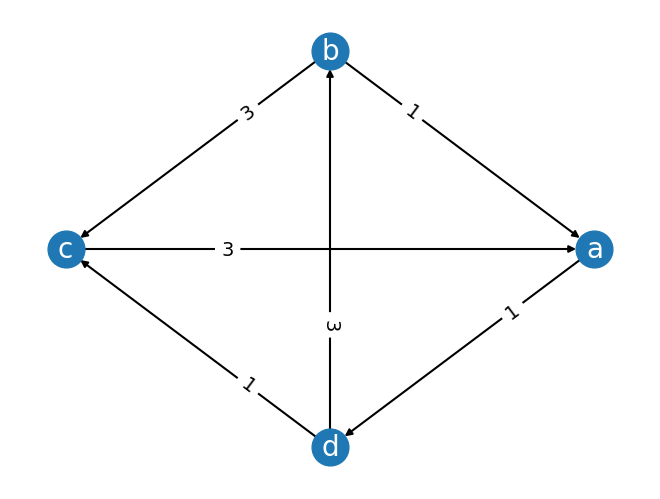

minimax: [3]
copeland: [1, 3]
condorecet winner: None


In [ ]:
num_trials = 10000

num_cands = 4
num_voters = 5

cmap = {0:"a", 1:"b", 2:"c", 3:"d", 4:"e", 5:"f", 6:"g"}
profiles = [generate_profile(num_cands, num_voters) for _ in range(num_trials)]
for prof in profiles:
    minimax_ws = minimax(prof)
    copleand_ws  = copeland(prof)
    cw = prof.condorcet_winner()
    if cw is None and len(minimax_ws) == 1  and minimax_ws != copleand_ws:
        prof = prof.anonymize()
        print(prof.to_latex(cmap=cmap))
        prof.display(cmap=cmap)
        prof.display_margin_graph(cmap=cmap)
        print("minimax:", minimax_ws)
        print("copeland:", copleand_ws)
        print("condorecet winner:", cw)
        break

In [62]:
from pref_voting.proportional_methods import *


# \begin{tabular}{ cccccc}
#   11 & 13 & 14 & 15 & 20 & 27 \\
# \hline
#   $E$ & $F$ & $C$ & $D$ & $A$ & $B$ \\
#   $F$ & $C$ & $D$ & $E$ & $B$ & $A$ \\
#   $C$ & $D$ & $E$ & $F$ & $E$ & $E$ \\
#   $D$ & $E$ & $F$ & $C$ & $F$ & $F$ \\
#   $A$ & $A$ & $A$ & $A$ & $C$ & $C$ \\
#   $B$ & $B$ & $B$ & $B$ & $D$ & $D$ \\
# \end{tabular}

a=0
b=1
c=2
d=3
e=4
f=5

cmap = {0:"a", 1:"c", 2:"b", 3:"f", 4:"e", 5:"d", 6:"g"}
prof = Profile(
   rankings = [
      [e, f, c, d, a, b],
      [f, c, d, e, a, b],
      [c, d, e, f, a, b],
      [d, e, f, c, a, b],
      [a, b, e, f, c, d],
      [b, a, e, f, c, d]
   ],
   #rcounts = [11, 13, 14, 15, 20, 27]
   rcounts = [11, 13, 12, 14, 18, 22]
)


print(90 // 3  + 1)
print(prof.num_voters)
print(prof.to_latex(cmap=cmap))
prof.display(cmap=cmap)
print([cmap[c] for c in stv_meek(prof, num_seats=2)])

31
90
\begin{tabular}{cccccc}
$11$ & $13$ & $12$ & $14$ & $18$ & $22$\\\hline 
$e$ & $d$ & $b$ & $f$ & $a$ & $c$\\ 
$d$ & $b$ & $f$ & $e$ & $c$ & $a$\\ 
$b$ & $f$ & $e$ & $d$ & $e$ & $e$\\ 
$f$ & $e$ & $d$ & $b$ & $d$ & $d$\\ 
$a$ & $a$ & $a$ & $a$ & $b$ & $b$\\ 
$c$ & $c$ & $c$ & $c$ & $f$ & $f$
\end{tabular}
+----+----+----+----+----+----+
| 11 | 13 | 12 | 14 | 18 | 22 |
+----+----+----+----+----+----+
| e  | d  | b  | f  | a  | c  |
| d  | b  | f  | e  | c  | a  |
| b  | f  | e  | d  | e  | e  |
| f  | e  | d  | b  | d  | d  |
| a  | a  | a  | a  | b  | b  |
| c  | c  | c  | c  | f  | f  |
+----+----+----+----+----+----+
['c', 'd']
